In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-04-13 10:21:54.230061


# Prepare processed data for GEO upload
We will prepare 3 processed adata objects for upload to GEO
1. The global adata object with all 480 genes included, including transgenes. This is used for reporter + cell identification. It is not used for dimensionality reduction or labeling, as the transgenes were removed for these steps.
2. The global adata object with scvi and umap dimensions and seurat predicted labels for all cell types. Cells are filtered to >50 transcripts/cell.
3. The neuron adata object with scvi and umap dimesions on neuron subset. This includes the final neuron labels, including the CGRPgamma subsets. Cells are filtered to >1000 transcripts/cell.

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 300

## Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR, DATA_DIR
print(BASE_DIR)

# Output
output_dir = BASE_DIR / "geo_organized"
os.makedirs(output_dir, exist_ok=True)
print(output_dir)

/home/workspace/DRG/spatial_mouse_drg_outputs/Kim
/home/workspace/DRG/spatial_mouse_drg_outputs/Kim/geo_organized


In [5]:
# global adata with transgenes included
adata_480_path = BASE_DIR / "data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad"
# global adata
adata_global_path = BASE_DIR / "data/h5ad/export_03/03b_seurat/adata-merged-labels.h5ad"
# neuron adata with final labels
adata_neurons_path = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"

# Reporter status table
reporters_path = BASE_DIR / "data/h5ad/export_03/03b_thresholds/reporter_classes_gaussian_thresholds.csv" 

## Load adata and reporter info

In [6]:
# adatas
adata_global_480 = sc.read_h5ad(adata_480_path)
adata_global = sc.read_h5ad(adata_global_path)
adata_neurons = sc.read_h5ad(adata_neurons_path)


In [7]:
# reporter positive classification
reporter_classes_updated_dual = pd.read_csv(reporters_path, index_col = 0)
reporter_classes_updated_dual.head()

,sample_id,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,reporter_status
aaadagcf-1,TMA00304,False,False,False,Negative
aaaihgjh-1,TMA00304,False,False,False,Negative
aabcohae-1,TMA00304,False,False,False,Negative
aabdncpn-1,TMA00304,False,False,False,Negative
aabkbaii-1,TMA00304,False,False,False,Negative


## Strip extra and unused adata components

In [8]:
def remove_adata_components(adata, remove_obs=None, remove_obsm=None, remove_obsp=None, remove_uns=None, remove_layers=None):
    """
    Removes specific keys/columns from AnnData components based on provided lists.
    
    Parameters:
    adata (AnnData): The object to clean.
    remove_obs, remove_obsm, remove_obsp, remove_uns, remove_layers (list): Keys to delete.
    
    Returns:
    AnnData: The cleaned object with specified components removed.
    """
    
    # Map the component name to the actual object attribute and its specific removal list
    mapping = {
        'obs': (adata.obs, remove_obs),
        'uns': (adata.uns, remove_uns),
        'obsm': (adata.obsm, remove_obsm),
        'layers': (adata.layers, remove_layers),
        'obsp': (adata.obsp, remove_obsp)
    }

    for name, (component_data, keys_to_remove) in mapping.items():
        if keys_to_remove is not None:
            for key in keys_to_remove:
                try:
                    if name == 'obs':
                        # Use .drop to handle the dataframe axis safely
                        adata.obs.drop(columns=[key], inplace=True)
                    else:
                        # Use del for dictionary-like components (obsm, uns, etc.)
                        del component_data[key]
                except (KeyError, ValueError):
                    print(f"Warning: Key '{key}' not found in adata.{name}. Skipping.")
                    
    return adata

In [9]:
# global 480
adata_global_480 = remove_adata_components(adata_global_480, 
                                           remove_obs=['batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'region_id'], 
                                           remove_obsm=['X_scVI_ModelB_480', 'X_umap'], 
                                           remove_obsp=['connectivities', 'distances'], 
                                           remove_uns=['_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_colors', 'neighbors', 'sample_id_colors', 'slide_id_colors', 'umap'],
                                          )

In [10]:
# global
adata_global = remove_adata_components(adata_global,
                                       remove_obs = ['scanvi_labels', 'scanvi_class', 'region_id'], # remove scanvi predictions since they are not used; region id redundant with sample_id
                                       remove_layers = ['log1p', 'normalized'] # keep counts in layers. adata.X is already log norm
                                          )

In [11]:
# add reporter info to adata_global
cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
adata_global.obs = adata_global.obs.join(reporter_classes_updated_dual[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']])

In [12]:
# neurons
adata_neurons = remove_adata_components(adata_neurons,
                                       remove_obs = ['scanvi_labels', 'scanvi_class', 'region_id',
                                                    'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status', 'innervation_pattern', # add these directly from updated csv
                                                     'neuron_recluster_seurat', # leiden clustering 
                                                      'neuron_labels'],  # repeated column
                                       remove_layers = ['log1p', 'normalized'] # keep counts in layers. adata.X is already log norm
                                          )

In [13]:
# add reporter info to adata_neurons
cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
adata_neurons.obs = adata_neurons.obs.join(reporter_classes_updated_dual[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']])

## Final adata contents

In [14]:
adata_global_480

AnnData object with n_obs × n_vars = 147036 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes'
    obsm: 'spatial'
    layers: 'counts'

In [15]:
adata_global

AnnData object with n_obs × n_vars = 147036 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'predi

In [16]:
adata_neurons

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'predic

## Save for GEO upload

In [68]:
output_dir

PosixPath('/home/workspace/data/temp/DRG/geo_organized')

In [69]:
adata_global_480.write(os.path.join(output_dir, 'adata_global_480.h5ad'), compression = 'gzip')
adata_global.write(os.path.join(output_dir, 'adata_global_processed.h5ad'), compression = 'gzip')
adata_neurons.write(os.path.join(output_dir, 'adata_neurons_processed.h5ad'), compression = 'gzip')

## Check adata loading 

In [70]:
adata_global_480_loaded = sc.read_h5ad(os.path.join(output_dir, 'adata_global_480.h5ad'))
adata_global_loaded = sc.read_h5ad(os.path.join(output_dir, 'adata_global_processed.h5ad'))
adata_neurons_loaded = sc.read_h5ad(os.path.join(output_dir, 'adata_neurons_processed.h5ad'))

In [71]:
adata_global_480_loaded

AnnData object with n_obs × n_vars = 147036 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes'
    obsm: 'spatial'
    layers: 'counts'

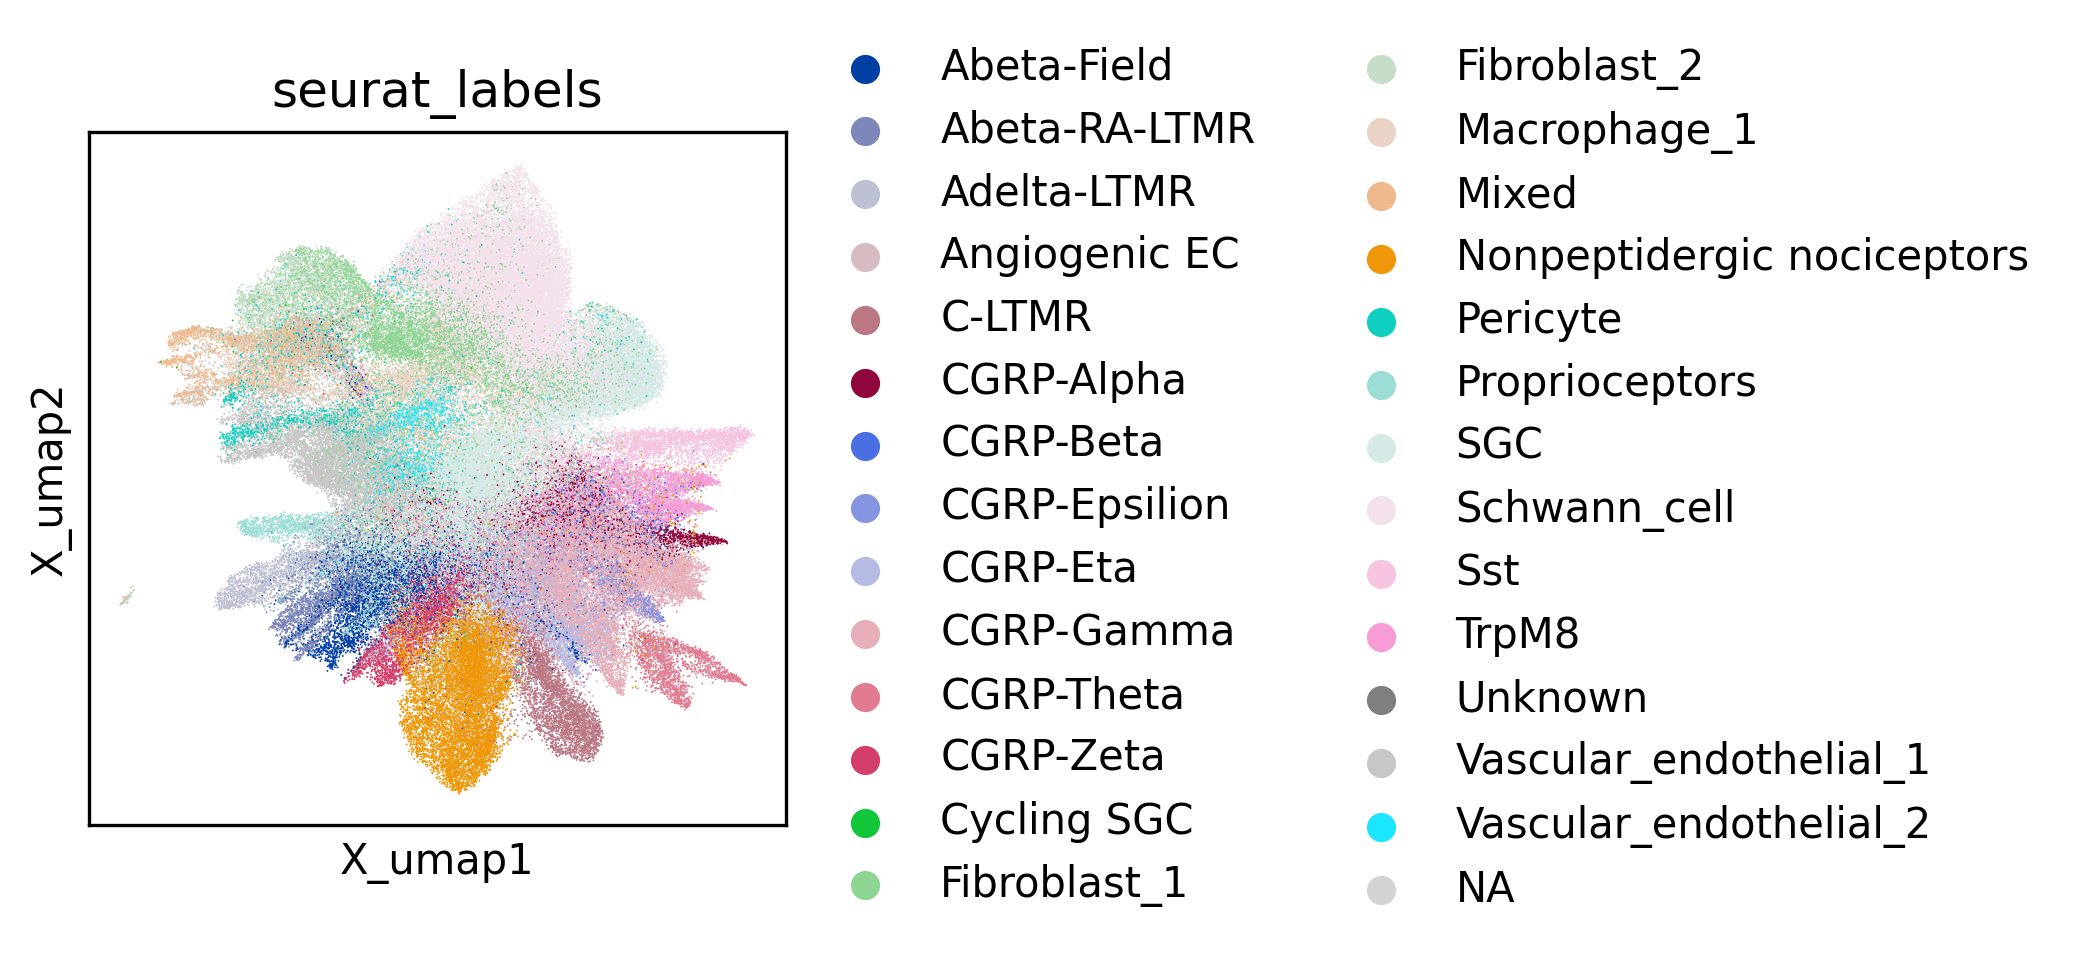

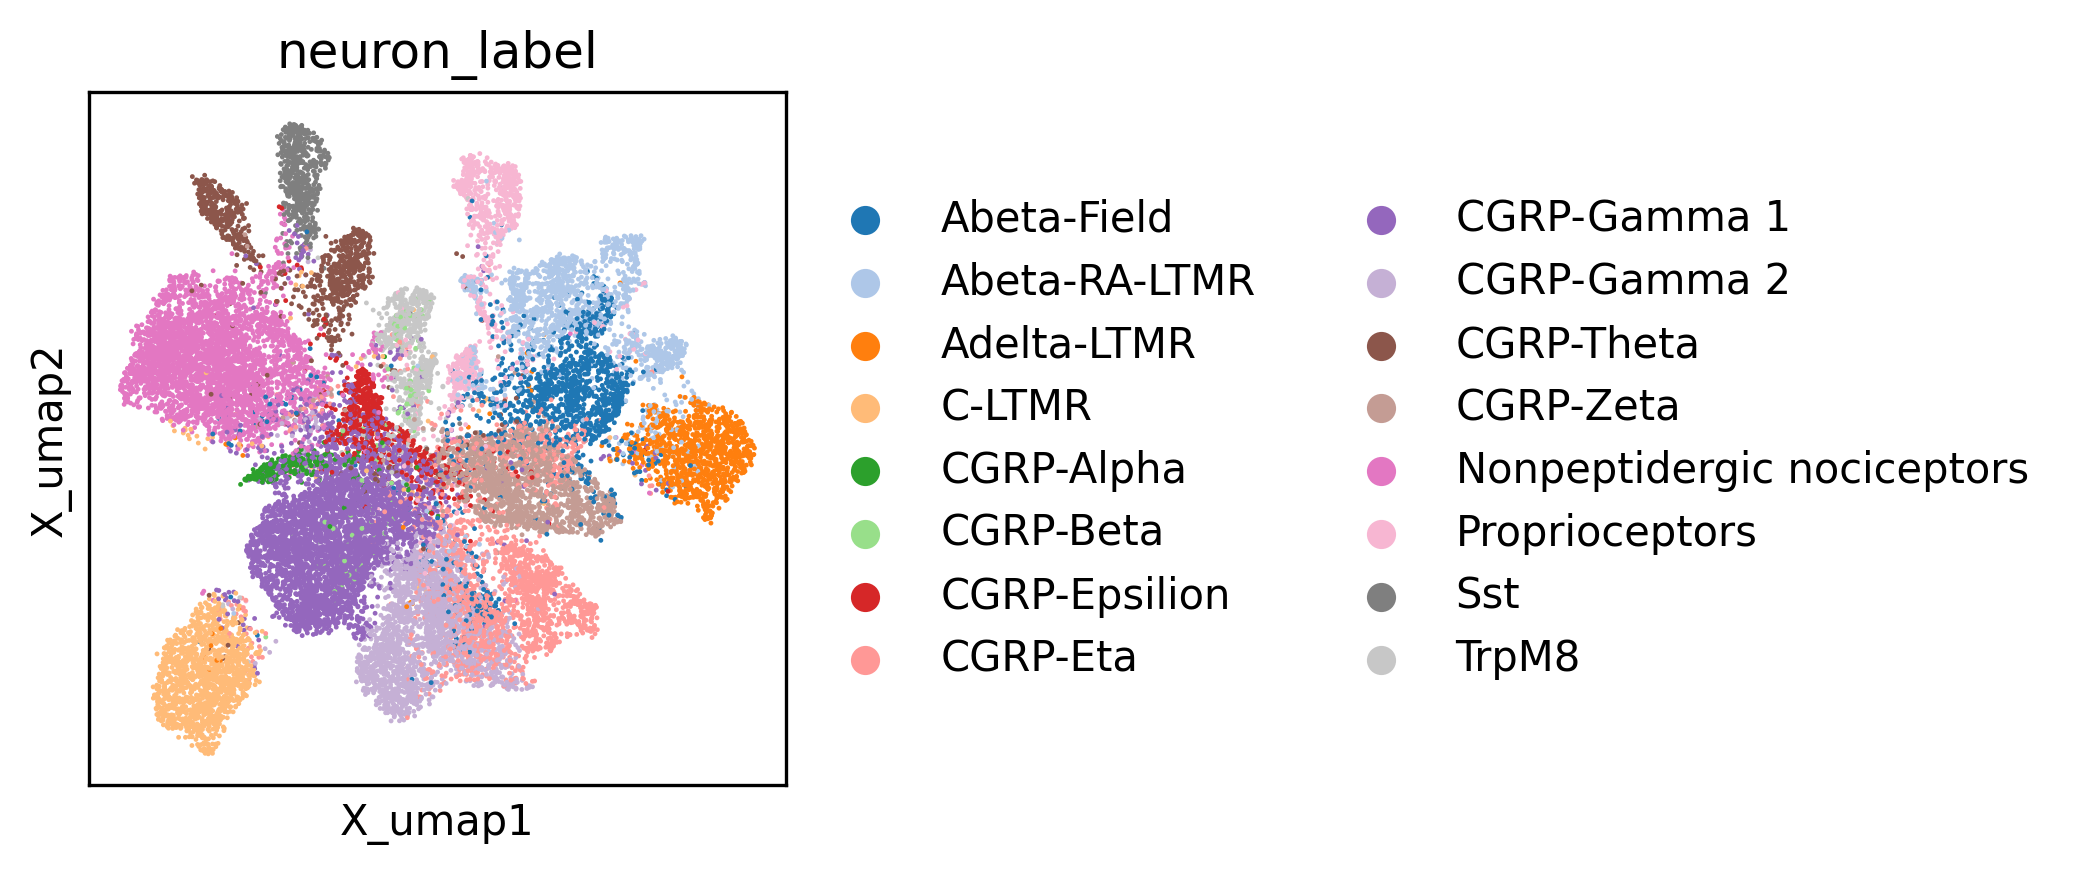

In [75]:
sc.pl.embedding(adata_global_loaded, basis = 'X_umap', color = 'seurat_labels')
sc.pl.embedding(adata_neurons_loaded, basis = 'X_umap', color = 'neuron_label')

## Zip

In [78]:
from pathlib import Path
import shutil

print(output_dir)

# destination folder (one level up from output_dir)
dest_folder = output_dir.parent

# full path for the zip 
zip_name = "drg_colon_bladder_Kim_processed_adata_20260302"
zip_path = dest_folder / zip_name

# zip
shutil.make_archive(str(zip_path), 'zip', str(output_dir))

print(f"Created: {zip_path}.zip")

/home/workspace/data/temp/DRG/geo_organized
Created: /home/workspace/data/temp/DRG/drg_colon_bladder_Kim_processed_adata_20260302.zip


In [82]:
zip_path

PosixPath('/home/workspace/data/temp/DRG/drg_colon_bladder_Kim_processed_adata_20260302')

## Gsutil upload to HISE

#### In IDE terminal:
gcloud auth login
#### Follow the prompts to authenticate your login in the browser and then proceed. You will have to follow the prompts in the browser and copy the required password into the terminal

#### After login is complete:
gcloud components install gsutil
#### Then follow prompts as applicable

#### Command to copy to project store:
nohup gsutil -m cp /home/workspace/data/temp/DRG/drg_colon_bladder_Kim_processed_adata_20260302.zip gs://wftini_mouseaifi-219b3400-2a33-483a-a457-d5272e41d7db
#### Once upload is complete, the nohup.out file will stop updating. Time taken for upload will depend on size of zip file

# HISE uuid after completion


"bead246c-6d91-47e9-9d56-b34138e674c8"